In [1]:
import uproot
import numpy as np
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import pandas as pd
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "1"


In [2]:
root_file = "/Volumes/HC/mcp_02_10m.root"

In [4]:
with uproot.open(root_file) as f:
    energy = f["PixelEDep"]["EnergyDep_Primary"].array(library="np")
energy = energy[np.isfinite(energy) & (energy > 0)]

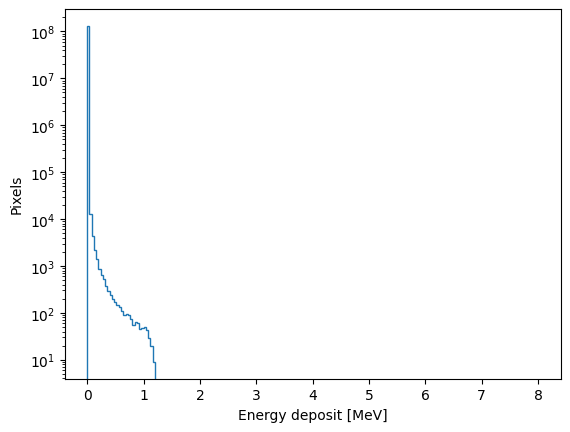

In [5]:
plt.hist(energy, bins=200, range=(0, 8), histtype="step")
plt.xlabel("Energy deposit [MeV]")
plt.ylabel("Pixels")
plt.yscale("log")
plt.show()

# MCP threshold lookup

In [3]:
import numpy as np

threshold_dir = "/Users/hongc/MCP_Analysis/data/thresholds"
grids = [(140, 280), (140, 280), (160, 320), (140, 280)]
tables = []

for module, (nx, ny) in enumerate(grids):
    f = np.load(f"{threshold_dir}/thresholds_module{module}.npz")
    keys = f["keys"].astype(int)
    order = np.argsort(keys)
    tables.append((keys[order], f["values"][order] / 1000, float(f["default"][0]) / 1000, nx, ny, keys.min()))

In [4]:
def threshold_ke(io_group, plane, pixel_y, pixel_z):
    io_group, plane, pixel_y, pixel_z = np.broadcast_arrays(io_group, plane, pixel_y, pixel_z)
    module = (io_group.astype(int) - 1) // 2
    out = np.empty(module.shape)

    for m in range(4):
        mask = module == m
        keys, values, default, nx, ny, offset = tables[m]
        key = offset + pixel_z[mask] + nx * (pixel_y[mask] + ny * plane[mask])
        pos = np.searchsorted(keys, key)
        found = (pos < len(keys)) & (keys[np.minimum(pos, len(keys) - 1)] == key)
        out[mask] = default
        index = np.flatnonzero(mask)[found]
        out.flat[index] = values[pos[found]]

    return out

In [5]:
k = 21.78

In [6]:
branches = [
    "EventID", "EnergyDep_Primary", "IOGroup", "Plane",
    "PixelY", "PixelZ", "x", "y", "z",
]
parts = {name: [] for name in branches}

with uproot.open(root_file) as f:
    for chunk in f["PixelEDep"].iterate(branches, step_size="50 MB", library="np"):
        e = chunk["EnergyDep_Primary"]
        thr = threshold_ke(
            chunk["IOGroup"], chunk["Plane"], chunk["PixelY"], chunk["PixelZ"]
        )
        keep = np.isfinite(e) & (e > 0) & (k * e > thr)
        for name in branches:
            parts[name].append(chunk[name][keep])

hit = {name: np.concatenate(parts[name]) for name in branches}
del parts

energy = hit["EnergyDep_Primary"]
threshold = threshold_ke(hit["IOGroup"], hit["Plane"], hit["PixelY"], hit["PixelZ"])


In [7]:
fiducial = (
    (hit["x"] >= -63.931) & (hit["x"] <= 63.931) &
    (hit["y"] >= -51.85) & (hit["y"] <= 51.85) &
    (((hit["z"] >= -54.32) & (hit["z"] <= -12.68)) |
     ((hit["z"] >= 12.68) & (hit["z"] <= 54.32)))
)

In [8]:
keep = np.isfinite(energy) & (energy > 0) & (k * energy > threshold) & fiducial
selected = {name: values[keep] for name, values in hit.items()}
print("Selected hits:", len(selected["EnergyDep_Primary"]))

Selected hits: 15511


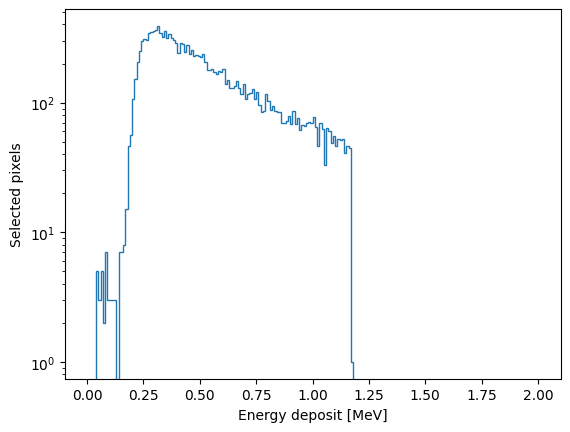

In [9]:
plt.hist(selected["EnergyDep_Primary"], bins=200, range=(0, 2), histtype="step")
plt.xlabel("Energy deposit [MeV]")
plt.ylabel("Selected pixels")
plt.yscale("log")
plt.show()

In [10]:
selected["ClusterID"] = np.empty(len(selected["EventID"]), dtype=int)

for event_id in np.unique(selected["EventID"]):
    mask = selected["EventID"] == event_id
    xyz = np.column_stack([
        selected["x"][mask],
        selected["y"][mask],
        selected["z"][mask],
    ])

    selected["ClusterID"][mask] = DBSCAN(
        eps=1.0,
        min_samples=1, n_jobs=1,
    ).fit_predict(xyz)

In [12]:
df = pd.DataFrame(selected)
df["Charge_ke"] = k * df["EnergyDep_Primary"]

clusters = (
    df.groupby(["EventID", "ClusterID"], as_index=False)
      .agg(
          NPixels=("EnergyDep_Primary", "size"),
          Energy_MeV=("EnergyDep_Primary", "sum"),
          Charge_ke=("Charge_ke", "sum"),
          x_cm=("x", "mean"),
          y_cm=("y", "mean"),
          z_cm=("z", "mean"),
      )
)
clusters.to_csv("clusters.csv", index=False)
clusters.head()

,EventID,ClusterID,NPixels,Energy_MeV,Charge_ke,x_cm,y_cm,z_cm
0,128,0,1,0.333109,7.255119,12.390731,-45.989361,-29.537904
1,541,0,1,0.277530,6.044613,34.030596,-31.981650,-24.695343
2,1212,0,1,0.713037,15.529943,30.039372,22.094661,-19.412549
3,1588,0,1,0.458390,9.983741,37.156684,11.685352,-31.739069
4,2059,0,1,0.731977,15.942464,-22.441621,-50.766240,-50.228849


In [13]:
selected = clusters.groupby("EventID").filter(lambda d: len(d) == 2).copy()

distance = selected.groupby("EventID")[["x_cm", "y_cm", "z_cm"]].agg(
    lambda v: v.iloc[1] - v.iloc[0]
)
distance = np.sqrt((distance**2).sum(axis=1))

selected["Distance_cm"] = selected["EventID"].map(distance)
selected = selected[selected["Distance_cm"] > 20].copy()

print("Selected events:", selected["EventID"].nunique())
selected.to_csv("selected.csv", index=False)
selected.head(10)

Selected events: 15


,EventID,ClusterID,NPixels,Energy_MeV,Charge_ke,x_cm,y_cm,z_cm,Distance_cm
161,97706,0,1,0.477941,10.409556,-14.822797,21.774070,-49.348383,30.816301
162,97706,1,1,0.630508,13.732468,-14.826923,21.780928,-18.532083,30.816301
1529,959292,0,1,0.272105,5.926444,-55.737422,-16.862842,38.342561,60.836749
1530,959292,1,1,0.284696,6.200682,-55.705880,-16.854219,-22.494179,60.836749
2503,1608768,0,1,0.451113,9.825240,-7.853156,-23.732114,23.814877,36.623934
2504,1608768,1,1,0.699949,15.244898,-7.850061,-23.724478,-12.809056,36.623934
3318,2127386,0,1,0.197901,4.310285,-45.653071,46.281674,46.266753,99.577251
3319,2127386,1,1,0.387470,8.439106,-45.611367,46.234948,-53.310479,99.577251
3409,2181733,0,1,0.287195,6.255117,-62.593937,-13.752280,50.669081,86.810499
3410,2181733,1,1,0.420088,9.149527,-62.536259,-13.740449,-36.141397,86.810499


In [16]:
angles = []

for event_id, blips in selected.groupby("EventID"):
    xyz = blips[["x_cm", "y_cm", "z_cm"]].to_numpy()
    delta = xyz[1] - xyz[0]
    distance = np.linalg.norm(delta)

    theta_z = np.degrees(
        np.arccos(np.clip(abs(delta[2]) / distance, 0, 1))
    )

    angles.append({
        "EventID": event_id,
        "Distance_cm": distance,
        "Theta_z_mrad": np.deg2rad(theta_z)* 1000,
    })

angles = pd.DataFrame(angles)
angles

,EventID,Distance_cm,Theta_z_mrad
0,97706,30.816301,0.259708
1,959292,60.836749,0.537485
2,1608768,36.623934,0.224970
3,2127386,99.577251,0.628955
4,2181733,86.810499,0.678246
5,2268130,47.629764,0.630749
6,4383097,73.163271,0.556017
7,5781136,44.107897,0.484777
8,6567591,46.749302,0.771176
9,7720172,53.352793,0.647575


In [3]:
res = pd.read_csv("selected_event_signals_0909.csv")

pi0_002 = res[
    (res["product"] == "pi0") &
    (res["mcp_mass_GeV"] == 0.02045833)&
    (res["Distance_cm"] >=20)
].copy()


In [4]:
print(len(pi0_002))

13


In [6]:
pi0_002["Theta_z_mrad"] = np.deg2rad(pi0_002["Theta_z_deg"]) * 1000

In [7]:
print(pi0_002["Theta_z_mrad"])

0     0.410189
1     0.428671
2     0.234775
3     0.563713
4     0.468979
6     0.599377
7     0.348418
8     0.077177
9     0.316009
11    0.408313
12    0.623336
13    0.285968
15    0.152112
Name: Theta_z_mrad, dtype: float64


In [19]:
res_2 = pd.read_csv("selected_event_signals_0910.csv")

pi0_002_2 = res_2[
    (res_2["product"] == "pi0") &
    (res_2["mcp_mass_GeV"] == 0.02045833)&
    (res_2["Distance_cm"] >=20)
].copy()
print(len(pi0_002_2))

11


In [15]:
selected = pd.read_csv("selected.csv")
delta = selected.groupby("EventID")[["x_cm", "y_cm", "z_cm"]].agg(
    lambda v: v.iloc[1] - v.iloc[0]
)
result = pd.DataFrame({
    "Distance_cm": np.sqrt((delta**2).sum(axis=1)),
    "Theta_z_rad": np.arctan2(
        np.hypot(delta["x_cm"], delta["y_cm"]), np.abs(delta["z_cm"])
    ),
}).reset_index()

result

,EventID,Distance_cm,Theta_z_rad
0,97706,30.816301,0.000260
1,959292,60.836749,0.000537
2,1608768,36.623934,0.000225
3,2127386,99.577251,0.000629
4,2181733,86.810499,0.000678
5,2268130,47.629764,0.000631
6,4383097,73.163271,0.000556
7,5781136,44.107897,0.000485
8,6567591,46.749302,0.000771
9,7720172,53.352793,0.000648
